# Day 2 - Linear Regression, SGD & Softmax Classification

### Core mental model

`Data → Model → Loss → backward() → gradients → optimizer/SGD → updated parameters`

After training:

`New Data → Trained Model → Prediction`

# 1. Linear Regression Intuition & Vectorization

> Source: D2L §3.1

In [1]:
%matplotlib inline
import math
import time
import numpy as np
import torch

In [2]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

In [3]:
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [4]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.18574 sec'

In [5]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00000 sec'

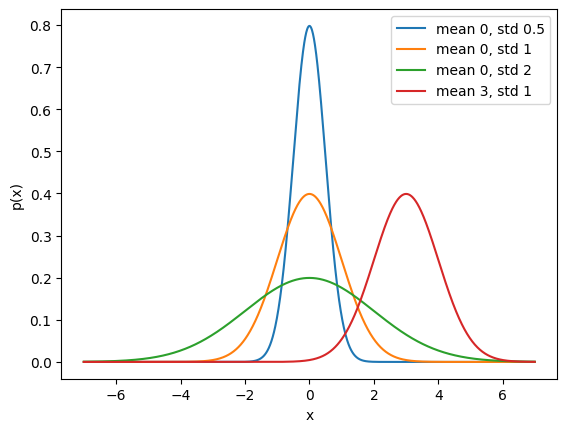

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt

# 正态分布概率密度函数
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

# x 轴
x = np.arange(-7, 7, 0.01)

# (均值, 标准差)
params = [(0, 0.5), (0, 1), (0, 2), (3, 1)]

# 画三条正态分布曲线
for mu, sigma in params:
    plt.plot(
        x,
        normal(x, mu, sigma),
        label=f"mean {mu}, std {sigma}"
    )

plt.xlabel("x")
plt.ylabel("p(x)")
plt.legend()
plt.show()

# 2. Linear Regression from Scratch

> Source: D2L §3.2

In [7]:
%matplotlib inline
import random
import torch

In [8]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [9]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.3930,  1.0607]) 
label: tensor([-0.2000])


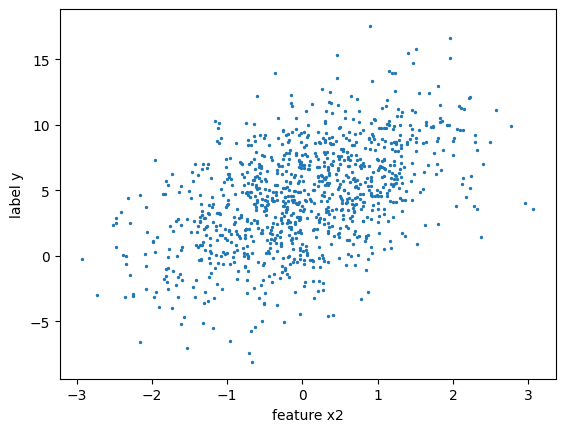

In [11]:
import matplotlib.pyplot as plt

plt.scatter(
    features[:, 0].detach().numpy(),
    labels.detach().numpy(),
    s=2
)

plt.xlabel("feature x2")
plt.ylabel("label y")
plt.show()

In [13]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [14]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.6927, -0.4023],
        [-0.6648,  3.2361],
        [-0.1568,  0.5057],
        [-0.1096,  1.2408],
        [-1.4633, -1.5117],
        [-0.0103, -0.8057],
        [ 0.6449, -0.6351],
        [-0.0929,  0.4755],
        [ 1.1786,  1.7511],
        [-0.3880,  0.2733]]) 
 tensor([[ 6.9684],
        [-8.1103],
        [ 2.1678],
        [-0.2304],
        [ 6.4102],
        [ 6.9212],
        [ 7.6607],
        [ 2.4146],
        [ 0.6040],
        [ 2.5019]])


In [15]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [16]:
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [17]:
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [18]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [19]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.023731
epoch 2, loss 0.000079
epoch 3, loss 0.000043


In [20]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0004, -0.0001], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0002], grad_fn=<RsubBackward1>)


# 3. PyTorch Concise Linear Regression

> Source: D2L §3.3

In [22]:
import torch
from torch.utils import data

def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

features, labels = synthetic_data(true_w, true_b, 1000)

In [23]:
dataset = data.TensorDataset(features, labels)

data_iter = data.DataLoader(
    dataset,
    batch_size=10,
    shuffle=True
)

In [24]:
next(iter(data_iter))

[tensor([[ 1.3570, -1.0120],
         [-0.1572, -0.6761],
         [-1.7802, -0.3681],
         [ 0.6224, -0.6617],
         [-0.8695,  1.8667],
         [-1.2049, -0.1159],
         [-0.3420,  1.3515],
         [-0.9918,  0.8909],
         [-0.2091, -1.3641],
         [-0.0191, -0.8082]]),
 tensor([[10.3492],
         [ 6.1798],
         [ 1.9008],
         [ 7.7045],
         [-3.8805],
         [ 2.1943],
         [-1.0909],
         [-0.8197],
         [ 8.4190],
         [ 6.9048]])]

In [25]:
# nn是神经网络的缩写
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [26]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [27]:
loss = nn.MSELoss()

In [28]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [31]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000107
epoch 2, loss 0.000107
epoch 3, loss 0.000107


In [32]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([-0.0009,  0.0004])
b的估计误差： tensor([-0.0002])


# 4. Fashion-MNIST & DataLoader

> Source: D2L §3.5

In [33]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

In [34]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0～1之间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

100.0%
100.0%
100.0%
100.0%


In [35]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [36]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [37]:
def get_fashion_mnist_labels(labels):  #@save
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [38]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [39]:
batch_size = 256

def get_dataloader_workers():  #@save
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

In [43]:
import time

start = time.perf_counter()

for X, y in train_iter:
    pass

elapsed = time.perf_counter() - start

print(f"{elapsed:.2f} sec")

14.08 sec


In [41]:
def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [42]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


# 5. Softmax Regression from Scratch

> Source: D2L §3.6

In [45]:
import torch
from torch.utils import data
from torchvision import datasets, transforms

batch_size = 256

# 1. 图片 → Tensor
transform = transforms.ToTensor()

# 2. 下载 Fashion-MNIST 训练集
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# 3. 下载 Fashion-MNIST 测试集
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# 4. Dataset → DataLoader
train_iter = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100.0%


In [46]:
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=False
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=False
)

print(len(train_dataset))
print(len(test_dataset))

60000
10000


In [47]:
train_iter = data.DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_iter = data.DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

X, y = next(iter(train_iter))

print(X.shape)
print(y.shape)

torch.Size([256, 1, 28, 28])
torch.Size([256])


In [49]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size = (num_inputs, num_outputs), requires_grad = True)
b = torch.zeros(num_outputs,requires_grad = True)

In [50]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1,keepdim=True)
    return X_exp / partition

In [60]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1,W.shape[0])),W) + b)

In [53]:
y = torch.tensor([0,2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [61]:
def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)),y])

cross_entropy(y_hat,y)

tensor([2.3026, 0.6931])

In [74]:
def evaluate_accuracy(net, data_iter):
    # 只有 nn.Module 才有 eval()
    if isinstance(net, torch.nn.Module):
        net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)

            pred = y_hat.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

In [75]:
evaluate_accuracy(net, test_iter)

0.0275

In [92]:
def train_epoch(net, train_iter, loss_fn, lr):

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in train_iter:

        # forward
        y_hat = net(X)

        # loss
        l = loss_fn(y_hat, y)

        # backward
        l.sum().backward()

        # SGD 更新 W、b
        sgd([W, b], lr, y.numel())

        # 统计
        total_loss += l.sum().item()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total_samples += y.numel()

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )

In [93]:
lr = 0.1
num_epochs = 10

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        net,
        train_iter,
        cross_entropy,
        lr
    )

    test_acc = evaluate_accuracy(net, test_iter)

    print(
        f"epoch {epoch + 1}, "
        f"loss {train_loss:.4f}, "
        f"train acc {train_acc:.4f}, "
        f"test acc {test_acc:.4f}"
    )

epoch 1, loss 0.4186, train acc 0.8569, test acc 0.8371
epoch 2, loss 0.4176, train acc 0.8577, test acc 0.8393
epoch 3, loss 0.4161, train acc 0.8573, test acc 0.8417
epoch 4, loss 0.4142, train acc 0.8587, test acc 0.8404
epoch 5, loss 0.4137, train acc 0.8587, test acc 0.8373
epoch 6, loss 0.4116, train acc 0.8588, test acc 0.8376
epoch 7, loss 0.4104, train acc 0.8592, test acc 0.8418
epoch 8, loss 0.4096, train acc 0.8595, test acc 0.8336
epoch 9, loss 0.4094, train acc 0.8601, test acc 0.8403
epoch 10, loss 0.4080, train acc 0.8608, test acc 0.8419


In [94]:
# Fashion-MNIST 的 10 个类别名称
def get_fashion_mnist_labels(labels):
    text_labels = [
        't-shirt', 'trouser', 'pullover', 'dress', 'coat',
        'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
    ]
    return [text_labels[int(i)] for i in labels]


# 从测试集拿一个 batch
X, y = next(iter(test_iter))

# 预测
with torch.no_grad():
    y_hat = net(X)
    y_pred = y_hat.argmax(dim=1)

# 看前 6 个预测结果
true_labels = get_fashion_mnist_labels(y[:6])
pred_labels = get_fashion_mnist_labels(y_pred[:6])

for true, pred in zip(true_labels, pred_labels):
    print(f"真实: {true:12s}  预测: {pred}")

真实: ankle boot    预测: ankle boot
真实: pullover      预测: pullover
真实: trouser       预测: trouser
真实: trouser       预测: trouser
真实: shirt         预测: shirt
真实: trouser       预测: trouser


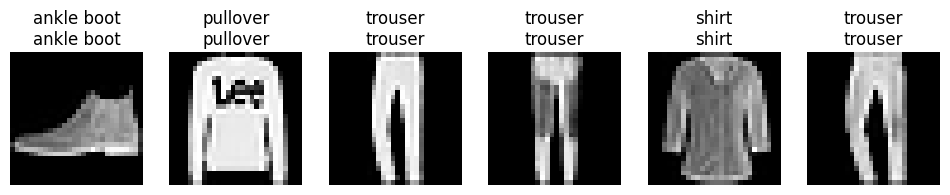

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(12, 2))

for i in range(6):
    axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f"{true_labels[i]}\n{pred_labels[i]}"
    )
    axes[i].axis('off')

plt.show()

# 6. PyTorch Concise Softmax Regression

> Source: D2L §3.7

In [96]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 10)
)

In [97]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [98]:
loss = nn.CrossEntropyLoss(reduction='none')

In [99]:
trainer = torch.optim.SGD(
    net.parameters(),
    lr=0.1
)

In [100]:
num_epochs = 10

for epoch in range(num_epochs):

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    net.train()

    for X, y in train_iter:

        # 1. Forward
        y_hat = net(X)

        # 2. Loss
        l = loss(y_hat, y)

        # 3. 清空上一轮梯度
        trainer.zero_grad()

        # 4. Backward
        l.mean().backward()

        # 5. 更新参数
        trainer.step()

        # 统计结果
        total_loss += l.sum().item()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total_samples += y.numel()

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    # 测试
    net.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_iter:

            y_hat = net(X)

            test_correct += (
                y_hat.argmax(dim=1) == y
            ).sum().item()

            test_total += y.numel()

    test_acc = test_correct / test_total

    print(
        f"epoch {epoch + 1}, "
        f"loss {train_loss:.4f}, "
        f"train acc {train_acc:.4f}, "
        f"test acc {test_acc:.4f}"
    )

epoch 1, loss 0.7877, train acc 0.7458, test acc 0.7838
epoch 2, loss 0.5694, train acc 0.8133, test acc 0.8101
epoch 3, loss 0.5248, train acc 0.8262, test acc 0.8143
epoch 4, loss 0.5019, train acc 0.8313, test acc 0.7948
epoch 5, loss 0.4852, train acc 0.8368, test acc 0.8175
epoch 6, loss 0.4736, train acc 0.8399, test acc 0.8288
epoch 7, loss 0.4649, train acc 0.8421, test acc 0.8277
epoch 8, loss 0.4573, train acc 0.8454, test acc 0.8096
epoch 9, loss 0.4526, train acc 0.8465, test acc 0.8280
epoch 10, loss 0.4476, train acc 0.8489, test acc 0.8323


# 7. Day 2 Summary

## Must Understand

- Linear regression predicts a continuous value.
- MSE measures regression error.
- Mini-batch SGD updates parameters using a batch-based gradient estimate.
- Softmax regression performs multiclass classification.
- The model produces **logits**; softmax can turn logits into probabilities.
- Cross entropy measures how well the model assigns probability to the correct class.
- `backward()` computes gradients; SGD / optimizer updates parameters.
- `argmax` converts class scores/probabilities into a predicted class.
- Inference does not need parameter updates, so `torch.no_grad()` is appropriate.

## Training vs. Inference

**Training**

`X → model → loss → backward → gradients → parameter update`

**Inference**

`X → trained model → logits/probabilities → argmax → predicted class`
